# Pipeline Completo — Fase A y Fase B
## Predicción preventiva de estrés con señales fisiológicas (WESAD)

---

### Arquitectura del proyecto

| Fase | Problema | Objetivo |
|------|----------|----------|
| **A** | Multiclase (4 estados) | Baseline experimental — demuestra que accuracy alta = persistencia de estado |
| **B** | Binario (precursor vs no-precursor) | Contribución principal — detectar señales fisiológicas previas al estrés |

### Señales utilizadas (del pecho, 700Hz originales)
- **ECG** → se extrae HRV (RMSSD, pNN50, HR medio) — más informativo que ECG crudo a 10Hz
- **EDA** → actividad electrodérmica en µS
- **Temp** → temperatura en °C
- **Resp** → respiración

### Definición operacional de estrés
Label=2 en WESAD corresponde al protocolo **TSST** (Trier Social Stress Test):
tarea aritmética y discurso público cronometrado. Es estrés cognitivo-social
controlado y validado experimentalmente, no estrés emocional espontáneo.

### Definición de ventana precursora (Fase B)
Si el estrés comienza en tiempo T, una ventana es precursora si:
- Su input termina en el intervalo `[T - PRECURSOR_ZONE, T - 1paso]`
- **Nunca** incluye muestras de la zona de stress en el input
- Proviene de un segmento de estado estable (label=1)

## 0. Instalación y configuración

In [1]:


import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, butter, filtfilt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─── RUTAS ────────────────────────────────────────────────────────────────────
WESAD_PATH = 'WESAD'   # Ajusta si tu carpeta está en otro lugar
SUBJECTS   = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']

# ─── PARÁMETROS GLOBALES ──────────────────────────────────────────────────────
FS_ORIGINAL  = 700     # Hz — frecuencia de muestreo original del pecho
FS_TARGET    = 10      # Hz — frecuencia objetivo después de downsample
DOWNSAMPLE_F = FS_ORIGINAL // FS_TARGET  # factor = 70

# Fase A — ventanas de continuidad
WINDOW_A  = 600   # pasos a 10Hz = 60 segundos de contexto
HORIZON_A = 200   # pasos a 10Hz = 20 segundos de anticipación
STRIDE_A  = 10    # pasos = 1 segundo (prueba también 50 = 5s si hay problemas de RAM)

# Fase B — ventanas precursoras
WINDOW_B         = 600   # pasos a 10Hz = 60s de contexto
PRECURSOR_ZONE_B = 300   # pasos a 10Hz = 30s antes del inicio de stress
STRIDE_B         = 10    # pasos = 1 segundo
NEG_RATIO        = 3     # negativos por cada positivo (balance 1:3)

# Etiquetas válidas de WESAD
VALID_LABELS  = [1, 2, 3, 4]   # baseline, stress, amusement, meditation
STRESS_LABEL  = 2
LABEL_NAMES   = {1:'Baseline', 2:'Stress', 3:'Amusement', 4:'Meditation'}

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Configuración cargada.')
print(f'Factor de downsampling: {DOWNSAMPLE_F}x ({FS_ORIGINAL}Hz → {FS_TARGET}Hz)')
print(f'Fase A — ventana: {WINDOW_A/10:.0f}s | horizonte: {HORIZON_A/10:.0f}s')
print(f'Fase B — ventana: {WINDOW_B/10:.0f}s | zona precursora: {PRECURSOR_ZONE_B/10:.0f}s')

Configuración cargada.
Factor de downsampling: 70x (700Hz → 10Hz)
Fase A — ventana: 60s | horizonte: 20s
Fase B — ventana: 60s | zona precursora: 30s


## 1. Extracción de HRV desde ECG a 700Hz

El ECG crudo a 10Hz pierde los picos R necesarios para calcular HRV.
Por eso extraemos métricas de HRV **antes** del downsampling, directamente
del ECG a 700Hz.

### Métricas extraídas por ventana de 60s:
- **HR_mean** — frecuencia cardíaca media (bpm)
- **RMSSD** — raíz cuadrada de diferencias sucesivas de intervalos RR (refleja actividad parasimpática)
- **pNN50** — porcentaje de intervalos RR consecutivos que difieren más de 50ms (sensible a estrés)

Estas tres métricas reemplazan el ECG crudo downsampleado.

In [2]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=700, order=3):
    """Filtro pasa-banda para limpiar ECG antes de detectar picos R."""
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal.flatten())


def extract_hrv_features(ecg_segment, fs=700):
    """
    Extrae HR_mean, RMSSD y pNN50 de un segmento de ECG a fs Hz.
    
    Parámetros
    ----------
    ecg_segment : array 1D, segmento de ECG en voltios/mV
    fs          : frecuencia de muestreo en Hz
    
    Retorna
    -------
    dict con hr_mean, rmssd, pnn50
    Retorna NaN si no se detectan suficientes picos.
    """
    try:
        # 1. Filtrar ECG
        ecg_filt = bandpass_filter(ecg_segment, fs=fs)
        
        # 2. Detectar picos R
        # min_distance: 0.3s entre picos (200bpm máximo fisiológico)
        min_dist = int(0.3 * fs)
        peaks, _ = find_peaks(ecg_filt, distance=min_dist, height=np.percentile(ecg_filt, 75))
        
        if len(peaks) < 3:
            return {'hr_mean': np.nan, 'rmssd': np.nan, 'pnn50': np.nan}
        
        # 3. Intervalos RR en milisegundos
        rr_intervals = np.diff(peaks) / fs * 1000  # ms
        
        # Filtrar intervalos fisiológicamente imposibles (300ms-2000ms = 30-200bpm)
        rr_valid = rr_intervals[(rr_intervals > 300) & (rr_intervals < 2000)]
        
        if len(rr_valid) < 2:
            return {'hr_mean': np.nan, 'rmssd': np.nan, 'pnn50': np.nan}
        
        # 4. Métricas HRV
        hr_mean = 60000 / np.mean(rr_valid)          # bpm
        diff_rr = np.diff(rr_valid)
        rmssd   = np.sqrt(np.mean(diff_rr ** 2))     # ms
        pnn50   = np.mean(np.abs(diff_rr) > 50) * 100  # %
        
        return {'hr_mean': hr_mean, 'rmssd': rmssd, 'pnn50': pnn50}
    
    except Exception:
        return {'hr_mean': np.nan, 'rmssd': np.nan, 'pnn50': np.nan}


print('Funciones HRV definidas.')
print('Métricas a extraer: HR_mean (bpm), RMSSD (ms), pNN50 (%)')

Funciones HRV definidas.
Métricas a extraer: HR_mean (bpm), RMSSD (ms), pNN50 (%)


## 2. Carga y procesamiento de señales por sujeto

Para cada sujeto:
1. Leer el `.pkl` original
2. Extraer señales del pecho (ECG, EDA, Temp, Resp) a 700Hz
3. Convertir etiquetas a 10Hz (downsampling por moda)
4. Downsamplear EDA, Temp, Resp de 700Hz a 10Hz (media por ventana de 70 muestras)
5. Extraer HRV por ventanas de 60s (evaluado cada 1s = stride de 70 muestras)
6. Normalización Z-score por sujeto (usando solo datos de entrenamiento en el split final)

In [3]:
def load_subject(subject_id, wesad_path):
    """
    Carga y procesa las señales de un sujeto desde su .pkl.
    
    Retorna
    -------
    df : DataFrame a 10Hz con columnas:
         [EDA, Temp, Resp, HR_mean, RMSSD, pNN50, Label, Subject_ID]
    """
    path = f'{wesad_path}/{subject_id}/{subject_id}.pkl'
    
    with open(path, 'rb') as f:
        raw = pickle.load(f, encoding='latin1')
    
    chest = raw['signal']['chest']
    label_700 = np.array(raw['label']).flatten()
    
    ecg  = np.array(chest['ECG']).flatten()
    eda  = np.array(chest['EDA']).flatten()
    temp = np.array(chest['Temp']).flatten()
    resp = np.array(chest['Resp']).flatten()
    
    T = len(ecg)
    F = DOWNSAMPLE_F   # 70
    n_steps_10hz = T // F
    
    # ── Downsample señales continuas (media por bloque de 70) ─────────────────
    eda_10  = eda[:n_steps_10hz*F].reshape(n_steps_10hz, F).mean(axis=1)
    temp_10 = temp[:n_steps_10hz*F].reshape(n_steps_10hz, F).mean(axis=1)
    resp_10 = resp[:n_steps_10hz*F].reshape(n_steps_10hz, F).mean(axis=1)
    
    # ── Downsample etiquetas (moda por bloque de 70) ──────────────────────────
    label_10 = np.array([
        int(stats.mode(label_700[i*F:(i+1)*F], keepdims=True).mode[0])
        for i in range(n_steps_10hz)
    ])
    
    # ── Extraer HRV por ventana deslizante de 60s evaluada cada 1s ───────────
    # Ventana HRV a 700Hz = 60s * 700 = 42000 muestras
    # Stride HRV a 700Hz  = 1s  * 700 = 700 muestras
    hrv_window_samples = 60 * FS_ORIGINAL   # 42000
    hrv_stride_samples = 1  * FS_ORIGINAL   # 700
    
    hr_arr   = np.full(n_steps_10hz, np.nan)
    rmssd_arr = np.full(n_steps_10hz, np.nan)
    pnn50_arr = np.full(n_steps_10hz, np.nan)
    
    # Cada paso a 10Hz corresponde a 70 muestras a 700Hz
    # Calculamos HRV para cada segundo (cada 700 muestras)
    n_hrv_steps = (T - hrv_window_samples) // hrv_stride_samples
    
    for i in range(n_hrv_steps):
        start_700 = i * hrv_stride_samples
        end_700   = start_700 + hrv_window_samples
        hrv = extract_hrv_features(ecg[start_700:end_700], fs=FS_ORIGINAL)
        
        # El resultado corresponde al índice i+60 a 10Hz
        # (porque necesita 60s de historia para calcularse)
        idx_10hz = i + 600   # 60s * 10Hz = 600 pasos de offset
        if idx_10hz < n_steps_10hz:
            hr_arr[idx_10hz]    = hrv['hr_mean']
            rmssd_arr[idx_10hz] = hrv['rmssd']
            pnn50_arr[idx_10hz] = hrv['pnn50']
    
    # ── Construir DataFrame ───────────────────────────────────────────────────
    df = pd.DataFrame({
        'EDA'       : eda_10,
        'Temp'      : temp_10,
        'Resp'      : resp_10,
        'HR_mean'   : hr_arr,
        'RMSSD'     : rmssd_arr,
        'pNN50'     : pnn50_arr,
        'Label'     : label_10,
        'Subject_ID': subject_id
    })
    
    # Filtrar solo etiquetas válidas y eliminar primeros 300s (nerviosismo inicial)
    df = df[df['Label'].isin(VALID_LABELS)].reset_index(drop=True)
    df = df.iloc[300*FS_TARGET:].reset_index(drop=True)   # 300s * 10Hz = 3000 filas
    
    # ── Z-Score por sujeto (señales continuas) ────────────────────────────────
    for col in ['EDA','Temp','Resp']:
        mean, std = df[col].mean(), df[col].std()
        df[col] = (df[col] - mean) / (std + 1e-8)
    
    # HRV: normalizar ignorando NaN
    for col in ['HR_mean','RMSSD','pNN50']:
        mean = df[col].mean(skipna=True)
        std  = df[col].std(skipna=True)
        df[col] = (df[col] - mean) / (std + 1e-8)
    
    return df


print('Función load_subject definida.')
print('Señales de salida: EDA, Temp, Resp, HR_mean, RMSSD, pNN50')
print('ECG crudo eliminado — reemplazado por métricas HRV')

Función load_subject definida.
Señales de salida: EDA, Temp, Resp, HR_mean, RMSSD, pNN50
ECG crudo eliminado — reemplazado por métricas HRV


In [5]:
# ─── Cargar todos los sujetos ─────────────────────────────────────────────────
# ADVERTENCIA: esta celda puede tardar 10-20 minutos en Colab
# porque extrae HRV de señales a 700Hz para cada sujeto
# Se guarda el resultado para no tener que recalcular

import os

PROCESSED_PATH = 'WESAD/wesad_procesado_hrv.csv'

if os.path.exists(PROCESSED_PATH):
    print('Cargando dataset procesado desde disco...')
    df_all = pd.read_csv(PROCESSED_PATH)
    print(f'Dataset cargado: {df_all.shape}')
else:
    print('Procesando sujetos (esto tarda ~15 minutos)...')
    dfs = []
    for subj in SUBJECTS:
        print(f'  Procesando {subj}...', end=' ')
        try:
            df_s = load_subject(subj, WESAD_PATH)
            dfs.append(df_s)
            nan_pct = df_s[['HR_mean','RMSSD','pNN50']].isna().mean().mean() * 100
            print(f'{len(df_s):,} filas | NaN HRV: {nan_pct:.1f}%')
        except Exception as e:
            print(f'ERROR: {e}')
    
    df_all = pd.concat(dfs, ignore_index=True)
    df_all.to_csv(PROCESSED_PATH, index=False)
    print(f'\nGuardado en: {PROCESSED_PATH}')
    print(f'Shape final: {df_all.shape}')

SIGNALS_A = ['EDA','Temp','Resp','HR_mean','RMSSD','pNN50']
print(f'\nSeñales para modelado: {SIGNALS_A}')

Procesando sujetos (esto tarda ~15 minutos)...
  Procesando S2... 25,890 filas | NaN HRV: 97.9%
  Procesando S3... 26,350 filas | NaN HRV: 98.1%
  Procesando S4... 26,700 filas | NaN HRV: 95.8%
  Procesando S5... 27,110 filas | NaN HRV: 96.3%
  Procesando S6... 26,890 filas | NaN HRV: 100.0%
  Procesando S7... 26,880 filas | NaN HRV: 93.4%
  Procesando S8... 27,050 filas | NaN HRV: 94.7%
  Procesando S9... 26,900 filas | NaN HRV: 92.5%
  Procesando S10... 27,730 filas | NaN HRV: 92.4%
  Procesando S11... 27,190 filas | NaN HRV: 92.9%
  Procesando S13... 27,210 filas | NaN HRV: 91.9%
  Procesando S14... 27,210 filas | NaN HRV: 89.6%
  Procesando S15... 27,270 filas | NaN HRV: 93.8%
  Procesando S16... 27,130 filas | NaN HRV: 91.9%
  Procesando S17... 27,070 filas | NaN HRV: 90.6%

Guardado en: WESAD/wesad_procesado_hrv.csv
Shape final: (404580, 8)

Señales para modelado: ['EDA', 'Temp', 'Resp', 'HR_mean', 'RMSSD', 'pNN50']


## 3. Análisis de transiciones
Antes de construir ventanas, visualizamos cuántas transiciones hacia stress
tiene cada sujeto y cuántas ventanas precursoras generará.

In [6]:
def find_stress_onsets(df_subject):
    """
    Encuentra los índices donde comienza el estado de stress (label=2)
    precedido por un estado no-stress.
    """
    labels = df_subject['Label'].values
    onsets = []
    for i in range(1, len(labels)):
        if labels[i] == STRESS_LABEL and labels[i-1] != STRESS_LABEL:
            onsets.append(i)
    return onsets


print('=== ANÁLISIS DE TRANSICIONES POR SUJETO ===')
print(f'{"Sujeto":8} {"Transiciones":>13} {"Ventanas precursoras":>21} {"Estado previo":>15}')
print('-' * 65)

total_precursores = 0
for subj in SUBJECTS:
    df_s = df_all[df_all['Subject_ID'] == subj].reset_index(drop=True)
    onsets = find_stress_onsets(df_s)
    
    # Contar cuántas ventanas precursoras generaría cada onset
    ventanas = 0
    for onset in onsets:
        # La zona precursora va desde onset-PRECURSOR_ZONE_B hasta onset-1
        # Una ventana de tamaño WINDOW_B termina en onset-1 como máximo
        # y empieza en onset-1-WINDOW_B como mínimo
        # Con stride STRIDE_B
        zone_start = max(WINDOW_B, onset - PRECURSOR_ZONE_B)
        zone_end   = onset - 1
        if zone_end > zone_start:
            ventanas += (zone_end - zone_start) // STRIDE_B
    
    # Estado previo al stress
    estado_previo = 'N/A'
    if onsets:
        idx_prev = onsets[0] - 1
        if idx_prev >= 0:
            estado_previo = LABEL_NAMES.get(df_s['Label'].iloc[idx_prev], '?')
    
    total_precursores += ventanas
    print(f'{subj:8} {len(onsets):>13} {ventanas:>21} {estado_previo:>15}')

print('-' * 65)
print(f'{"TOTAL":8} {"":>13} {total_precursores:>21}')
print(f'\nNegativas estimadas (ratio 1:{NEG_RATIO}): {total_precursores * NEG_RATIO}')
print(f'Dataset Fase B estimado: {total_precursores * (1 + NEG_RATIO)} ventanas')

=== ANÁLISIS DE TRANSICIONES POR SUJETO ===
Sujeto    Transiciones  Ventanas precursoras   Estado previo
-----------------------------------------------------------------
S2                   1                    29        Baseline
S3                   1                    29        Baseline
S4                   1                    29      Meditation
S5                   1                    29      Meditation
S6                   1                    29        Baseline
S7                   1                    29      Meditation
S8                   1                    29      Meditation
S9                   1                    29        Baseline
S10                  1                    29      Meditation
S11                  1                    29        Baseline
S13                  1                    29      Meditation
S14                  1                    29        Baseline
S15                  1                    29      Meditation
S16                  1              

## 4. Construcción del dataset — Fase A
Multiclase, 4 estados, sliding window con horizonte de 20s.
Ventanas donde input y target son el mismo estado (continuidad).

In [8]:
def build_windows_phase_A(df_subject, signals, window, horizon, stride):
    """
    Genera ventanas para Fase A (multiclase, continuidad + transición).
    Descarta ventanas con cambio de etiqueta dentro del input.
    Target: etiqueta en t + horizon pasos.
    """
    data      = df_subject[signals].values
    label_arr = df_subject['Label'].values
    T         = len(data)
    
    # Rellenar NaN de HRV con interpolación lineal
    for col_idx in range(data.shape[1]):
        col = data[:, col_idx]
        nans = np.isnan(col)
        for col_idx in range(data.shape[1]):
            col = data[:, col_idx]
            nans = np.isnan(col)
    
        if nans.all():
            # Caso crítico: toda la columna es NaN
            data[:, col_idx] = 0  # o np.nan_to_num, o eliminar señal
            continue
        
        if nans.any():
            idx = np.arange(T)
            data[:, col_idx] = np.interp(idx, idx[~nans], col[~nans])

    
    X_list, y_list = [], []
    
    for start in range(0, T - window - horizon + 1, stride):
        end_input  = start + window
        target_idx = end_input + horizon - 1
        
        # Descartar si hay cambio de etiqueta en el input
        if len(set(label_arr[start:end_input])) > 1:
            continue
        
        X_list.append(data[start:end_input])
        y_list.append(label_arr[target_idx] - 1)   # 0-indexed
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


print('Construyendo dataset Fase A...')
windows_A = {}

for subj in SUBJECTS:
    df_s = df_all[df_all['Subject_ID'] == subj].reset_index(drop=True)
    X_s, y_s = build_windows_phase_A(df_s, SIGNALS_A, WINDOW_A, HORIZON_A, STRIDE_A)
    windows_A[subj] = (X_s, y_s)
    print(f'  {subj}: {len(X_s):,} ventanas — shape: {X_s.shape}')

total_A = sum(len(v[1]) for v in windows_A.values())
print(f'\nTotal Fase A: {total_A:,} ventanas')
print(f'Shape por muestra: ({WINDOW_A}, {len(SIGNALS_A)}) = (pasos, señales)')

Construyendo dataset Fase A...
  S2: 2,274 ventanas — shape: (2274, 600, 6)
  S3: 2,320 ventanas — shape: (2320, 600, 6)
  S4: 2,355 ventanas — shape: (2355, 600, 6)
  S5: 2,396 ventanas — shape: (2396, 600, 6)
  S6: 2,374 ventanas — shape: (2374, 600, 6)
  S7: 2,373 ventanas — shape: (2373, 600, 6)
  S8: 2,390 ventanas — shape: (2390, 600, 6)
  S9: 2,375 ventanas — shape: (2375, 600, 6)
  S10: 2,458 ventanas — shape: (2458, 600, 6)
  S11: 2,404 ventanas — shape: (2404, 600, 6)
  S13: 2,406 ventanas — shape: (2406, 600, 6)
  S14: 2,406 ventanas — shape: (2406, 600, 6)
  S15: 2,412 ventanas — shape: (2412, 600, 6)
  S16: 2,398 ventanas — shape: (2398, 600, 6)
  S17: 2,392 ventanas — shape: (2392, 600, 6)

Total Fase A: 35,733 ventanas
Shape por muestra: (600, 6) = (pasos, señales)


## 5. Construcción del dataset — Fase B

### Definición de clases
- **Clase 1 (precursor):** ventanas cuyo input termina en los 30s previos al inicio de stress
- **Clase 0 (negativo):** ventanas de estados estables alejadas de cualquier transición a stress

### Negativos variados (crítico para evitar sesgos)
Los negativos se toman de **todos los estados estables** (baseline, amusement, meditation)
para que el modelo no aprenda simplemente 'baseline = no stress'.

In [10]:
def build_windows_phase_B(df_subject, signals, window, precursor_zone, stride, neg_ratio, rng):
    """
    Genera ventanas para Fase B (binario: precursor vs estable).
    
    Clase 1 — Precursor:
        Input termina en [onset - precursor_zone, onset - 1]
        Input NO contiene muestras de stress
        Input es de estado uniforme (sin mezcla)
    
    Clase 0 — Negativo:
        Input de estado estable, alejado de cualquier transición a stress
        (mínimo precursor_zone pasos de distancia)
        Muestreado aleatoriamente para balance neg_ratio:1
    """
    data      = df_subject[signals].values
    label_arr = df_subject['Label'].values
    T         = len(data)
    
    # Rellenar NaN de HRV
    for col_idx in range(data.shape[1]):
        col = data[:, col_idx]
        nans = np.isnan(col)
    
        if nans.all():
            # ⚠️ Caso crítico: toda la señal está vacía
            # Opción 1 (rápida):
            data[:, col_idx] = 0
            
            # Opción 2 (mejor para debug):
            # raise ValueError(f"Columna {signals[col_idx]} es completamente NaN en este sujeto")
            
            continue
        
        if nans.any():
            idx = np.arange(T)
            data[:, col_idx] = np.interp(idx, idx[~nans], col[~nans])
    
    # ── Encontrar onsets de stress ─────────────────────────────────────────────
    onsets = []
    for i in range(1, T):
        if label_arr[i] == STRESS_LABEL and label_arr[i-1] != STRESS_LABEL:
            onsets.append(i)
    
    if not onsets:
        return np.array([]), np.array([]), 0
    
    # ── Clase 1: ventanas precursoras ─────────────────────────────────────────
    X_pos, y_pos = [], []
    
    for onset in onsets:
        # Zona precursora: los 'precursor_zone' pasos antes del onset
        # El input termina como máximo en onset-1 (nunca toca stress)
        zone_end   = onset - 1
        zone_start = max(window, onset - precursor_zone)
        
        for end_input in range(zone_start, zone_end + 1, stride):
            start = end_input - window
            if start < 0:
                continue
            
            segment_labels = label_arr[start:end_input]
            
            # El input no debe contener stress ni mezcla de estados
            if STRESS_LABEL in segment_labels:
                continue
            if len(set(segment_labels)) > 1:
                continue
            
            X_pos.append(data[start:end_input])
            y_pos.append(1)
    
    n_pos = len(X_pos)
    if n_pos == 0:
        return np.array([]), np.array([]), 0
    
    # ── Clase 0: ventanas negativas variadas ──────────────────────────────────
    # Marcar zonas prohibidas (cerca de cualquier onset)
    forbidden = np.zeros(T, dtype=bool)
    for onset in onsets:
        # Prohibir desde onset-precursor_zone hasta el final del stress
        f_start = max(0, onset - precursor_zone)
        # Buscar el final del segmento de stress
        f_end = onset
        while f_end < T and label_arr[f_end] == STRESS_LABEL:
            f_end += 1
        forbidden[f_start:f_end] = True
    
    # Recopilar candidatos negativos
    neg_candidates = []
    non_stress_labels = [l for l in VALID_LABELS if l != STRESS_LABEL]
    
    for start in range(0, T - window + 1, stride * 5):  # stride*5 para no generar demasiados candidatos
        end_input = start + window
        
        # Verificar que la ventana no está en zona prohibida
        if forbidden[start:end_input].any():
            continue
        
        segment_labels = label_arr[start:end_input]
        
        # Estado uniforme, no stress
        if len(set(segment_labels)) > 1:
            continue
        if segment_labels[0] not in non_stress_labels:
            continue
        
        neg_candidates.append(start)
    
    # Muestrear neg_ratio negativos por cada positivo
    n_neg_target = min(n_pos * neg_ratio, len(neg_candidates))
    selected_neg = rng.choice(neg_candidates, size=n_neg_target, replace=False)
    
    X_neg = [data[s:s+window] for s in selected_neg]
    y_neg = [0] * n_neg_target
    
    # ── Combinar y retornar ────────────────────────────────────────────────────
    X = np.array(X_pos + X_neg, dtype=np.float32)
    y = np.array(y_pos + y_neg, dtype=np.int32)
    
    return X, y, n_pos


print('Construyendo dataset Fase B...')
rng_B = np.random.default_rng(RANDOM_SEED)
windows_B = {}
total_pos_B = 0

for subj in SUBJECTS:
    df_s = df_all[df_all['Subject_ID'] == subj].reset_index(drop=True)
    X_s, y_s, n_pos = build_windows_phase_B(
        df_s, SIGNALS_A, WINDOW_B, PRECURSOR_ZONE_B, STRIDE_B, NEG_RATIO, rng_B
    )
    if len(X_s) > 0:
        windows_B[subj] = (X_s, y_s)
        total_pos_B += n_pos
        n_neg = (y_s == 0).sum()
        print(f'  {subj}: {n_pos} precursores | {n_neg} negativos | total: {len(X_s)}')
    else:
        print(f'  {subj}: SIN TRANSICIONES — excluido de Fase B')

total_B = sum(len(v[1]) for v in windows_B.values())
print(f'\nTotal Fase B: {total_B} ventanas ({total_pos_B} positivos)')

Construyendo dataset Fase B...
  S2: 30 precursores | 90 negativos | total: 120
  S3: 30 precursores | 90 negativos | total: 120
  S4: 30 precursores | 90 negativos | total: 120
  S5: 30 precursores | 90 negativos | total: 120
  S6: 30 precursores | 90 negativos | total: 120
  S7: 30 precursores | 90 negativos | total: 120
  S8: 30 precursores | 90 negativos | total: 120
  S9: 30 precursores | 90 negativos | total: 120
  S10: 30 precursores | 90 negativos | total: 120
  S11: 30 precursores | 90 negativos | total: 120
  S13: 30 precursores | 90 negativos | total: 120
  S14: 30 precursores | 90 negativos | total: 120
  S15: 30 precursores | 90 negativos | total: 120
  S16: 30 precursores | 90 negativos | total: 120
  S17: 30 precursores | 90 negativos | total: 120

Total Fase B: 1800 ventanas (450 positivos)


## 6. LOSO — Leave-One-Subject-Out completo
Iteramos los 15 sujetos. Cada uno es el sujeto de prueba una vez.
El resultado final es la media ± desviación estándar de las 15 iteraciones.

In [11]:
from sklearn.utils.class_weight import compute_class_weight

def loso_splits(windows_dict, subjects):
    """
    Generador que produce los 15 splits LOSO.
    Cada iteración: 14 sujetos train, 1 sujeto test.
    
    Yield
    -----
    X_train, y_train, X_test, y_test, test_subject, class_weight_dict
    """
    valid_subjects = [s for s in subjects if s in windows_dict]
    
    for test_subj in valid_subjects:
        train_subjs = [s for s in valid_subjects if s != test_subj]
        
        X_train = np.concatenate([windows_dict[s][0] for s in train_subjs], axis=0)
        y_train = np.concatenate([windows_dict[s][1] for s in train_subjs], axis=0)
        X_test, y_test = windows_dict[test_subj]
        
        # Class weights calculados solo sobre train
        classes = np.unique(y_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, weights))
        
        yield X_train, y_train, X_test, y_test, test_subj, class_weight_dict


# Verificar splits de Fase A
print('=== VERIFICACIÓN LOSO — FASE A ===')
for i, (X_tr, y_tr, X_te, y_te, subj, cw) in enumerate(loso_splits(windows_A, SUBJECTS)):
    print(f'  Test={subj}: train={len(y_tr):,} | test={len(y_te):,} | class_weights={cw}')

print()
print('=== VERIFICACIÓN LOSO — FASE B ===')
for i, (X_tr, y_tr, X_te, y_te, subj, cw) in enumerate(loso_splits(windows_B, SUBJECTS)):
    n_pos_te = (y_te == 1).sum()
    n_neg_te = (y_te == 0).sum()
    print(f'  Test={subj}: train={len(y_tr)} | test pos={n_pos_te} neg={n_neg_te} | cw={cw}')

=== VERIFICACIÓN LOSO — FASE A ===
  Test=S2: train=33,459 | test=2,274 | class_weights={np.int32(0): np.float64(0.7494624137622077), np.int32(1): np.float64(0.9812023460410557), np.int32(2): np.float64(1.906713015728288), np.int32(3): np.float64(0.8911943319838057)}
  Test=S3: train=33,413 | test=2,320 | class_weights={np.int32(0): np.float64(0.7481639050604568), np.int32(1): np.float64(0.982735294117647), np.int32(2): np.float64(1.9097508001828989), np.int32(3): np.float64(0.8911083848943887)}
  Test=S4: train=33,378 | test=2,355 | class_weights={np.int32(0): np.float64(0.7485870637839778), np.int32(1): np.float64(0.9811287477954145), np.int32(2): np.float64(1.9064427690198766), np.int32(3): np.float64(0.8925553535137448)}
  Test=S5: train=33,337 | test=2,396 | class_weights={np.int32(0): np.float64(0.7503601332493023), np.int32(1): np.float64(0.9810771041789288), np.int32(2): np.float64(1.9049714285714285), np.int32(3): np.float64(0.8904113247863248)}
  Test=S6: train=33,359 | test=

## 7. Visualización de ventanas precursoras
Verificar visualmente que las ventanas precursoras muestran
la dinámica fisiológica esperada antes del onset de stress.

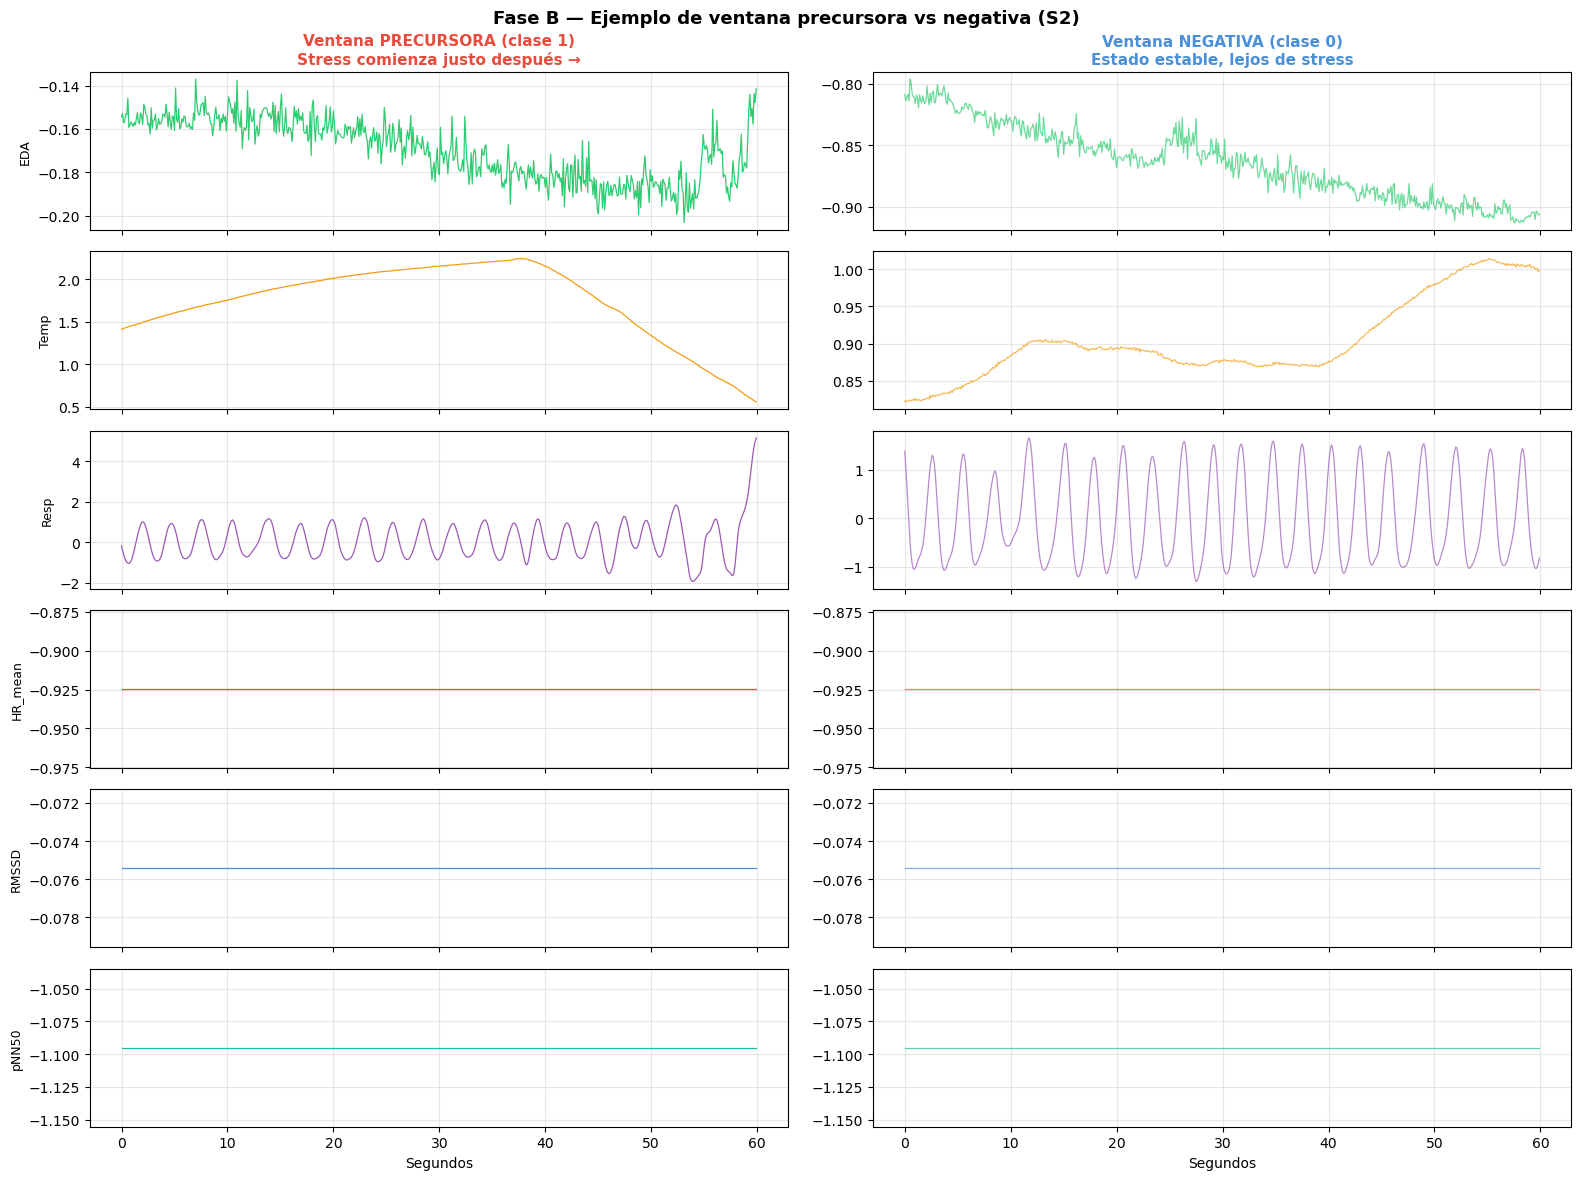

Si EDA/HR_mean muestran tendencia creciente en precursora → señal fisiológica real detectada.


In [12]:
# Elegir un sujeto con transiciones y graficar una ventana precursora vs una negativa
subj_demo = [s for s in SUBJECTS if s in windows_B][0]
X_b, y_b = windows_B[subj_demo]

idx_pos = np.where(y_b == 1)[0][0]
idx_neg = np.where(y_b == 0)[0][0]
tiempo  = np.arange(WINDOW_B) / FS_TARGET

fig, axes = plt.subplots(len(SIGNALS_A), 2, figsize=(16, 12), sharex=True)
fig.suptitle(f'Fase B — Ejemplo de ventana precursora vs negativa ({subj_demo})',
             fontsize=13, fontweight='bold')

colors_sig = ['#2ECC71','#F39C12','#9B59B6','#E74C3C','#4A90D9','#1ABC9C']

for i, sig in enumerate(SIGNALS_A):
    # Precursora
    axes[i, 0].plot(tiempo, X_b[idx_pos, :, i], color=colors_sig[i], linewidth=0.9)
    axes[i, 0].set_ylabel(sig, fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)
    
    # Negativa
    axes[i, 1].plot(tiempo, X_b[idx_neg, :, i], color=colors_sig[i], linewidth=0.9, alpha=0.7)
    axes[i, 1].grid(True, alpha=0.3)

axes[0, 0].set_title('Ventana PRECURSORA (clase 1)\nStress comienza justo después →', 
                      color='#E74C3C', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Ventana NEGATIVA (clase 0)\nEstado estable, lejos de stress',
                      color='#4A90D9', fontsize=11, fontweight='bold')
axes[-1, 0].set_xlabel('Segundos', fontsize=10)
axes[-1, 1].set_xlabel('Segundos', fontsize=10)

plt.tight_layout()
plt.show()
print('Si EDA/HR_mean muestran tendencia creciente en precursora → señal fisiológica real detectada.')

## 8. Guardar datasets para modelado
Guardamos en formato `.npz` para cargar directamente en el notebook de modelos.

In [14]:
import os

SAVE_DIR = 'WESAD'

# Guardar ventanas por sujeto para LOSO (no un split fijo)
# Fase A
np.savez_compressed(
    f'{SAVE_DIR}/fase_A_windows.npz',
    **{f'{s}_X': windows_A[s][0] for s in windows_A},
    **{f'{s}_y': windows_A[s][1] for s in windows_A},
    subjects=np.array(list(windows_A.keys()))
)

# Fase B
np.savez_compressed(
    f'{SAVE_DIR}/fase_B_windows.npz',
    **{f'{s}_X': windows_B[s][0] for s in windows_B},
    **{f'{s}_y': windows_B[s][1] for s in windows_B},
    subjects=np.array(list(windows_B.keys()))
)

size_A = os.path.getsize(f'{SAVE_DIR}/fase_A_windows.npz') / 1e6
size_B = os.path.getsize(f'{SAVE_DIR}/fase_B_windows.npz') / 1e6
print(f'Guardado fase_A_windows.npz: {size_A:.1f} MB')
print(f'Guardado fase_B_windows.npz: {size_B:.1f} MB')
print()
print('Para cargar en notebook de modelado:')
print("  data = np.load('fase_A_windows.npz', allow_pickle=True)")
print("  subjects = data['subjects']")
print("  X_S2 = data['S2_X']  |  y_S2 = data['S2_y']")

Guardado fase_A_windows.npz: 11.7 MB
Guardado fase_B_windows.npz: 9.8 MB

Para cargar en notebook de modelado:
  data = np.load('fase_A_windows.npz', allow_pickle=True)
  subjects = data['subjects']
  X_S2 = data['S2_X']  |  y_S2 = data['S2_y']


---
## Resumen del pipeline

| Elemento | Fase A | Fase B |
|----------|--------|--------|
| Problema | Multiclase (4 estados) | Binario (precursor vs estable) |
| Señales | EDA, Temp, Resp, HR, RMSSD, pNN50 | EDA, Temp, Resp, HR, RMSSD, pNN50 |
| Shape X | (n, 600, 6) | (n, 600, 6) |
| Target | estado en t+20s | 1=precursor stress / 0=estable |
| Validación | LOSO completo (15 folds) | LOSO completo (15 folds) |
| Desbalance | class_weight='balanced' | ratio 1:3 + class_weight |
| Leakage | ✅ Evitado | ✅ Evitado |
| Frontera | ✅ Ventanas mixtas descartadas | ✅ Input nunca toca stress |

## Siguiente paso — Fase 3: Modelado
1. LSTM baseline (Fase A)
2. GRU (Fase A)
3. LSTM binario (Fase B)
4. Comparación y análisis de errores por tipo de transición